In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import  train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from statsmodels.stats.contingency_tables import mcnemar

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [9]:
# Organize the excel file in a dataframe
df = pd.read_excel("Concrete_Data.xls")

# Seperate the target variable (Concrete compressive strength) from the rest "predicting" attributes
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '], axis=1)
# Target variable
y= df['Concrete compressive strength(MPa, megapascals) '].values

# Divide target variable in classes with threshold values
def categorize_strength(value):
    if value < 25.01:
        return 0  # low
    elif value < 55.02:
        return 1  # medium
    else:
        return 2  # high

y_classes = np.array([categorize_strength(val) for val in y])

In [10]:
num_low = np.sum(y_classes == 0)
num_medium = np.sum(y_classes == 1)
num_high = np.sum(y_classes == 2)

print(f"Class distribution:\n Low: {num_low}\n Medium: {num_medium}\n High: {num_high}")

Class distribution:
 Low: 295
 Medium: 588
 High: 147


In [11]:
# # Since the medium class has the most samples, the baseline model will predict this class everytime 

# X_train, X_test, y_train, y_test = train_test_split(X, y_classes, test_size=0.2, random_state=42, stratify=y_classes)

# baseline = DummyClassifier(strategy='most_frequent')
# baseline.fit(X_train, y_train)
# y_pred_base = baseline.predict(X_test)

# print(confusion_matrix(y_test, y_pred_base))
# print(classification_report(y_test, y_pred_base))   

In [12]:
# Cross-validation setup
K1 = K2 = 10
outer_cv = StratifiedKFold(n_splits=K1, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=K2, shuffle=True, random_state=42)

# Model Pipelines
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=42
    ))
])

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=2000,
        early_stopping=True,  
        random_state=42
    ))
])

# Logistic regression parameter range
logreg_params = {'logreg__C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Hidden layers
h1 = [16, 32, 64]
hidden_layer_sizes = [(h,) for h in h1] + [(h, h) for h in h1] 
print("Generated hidden layer for MLP:\n", hidden_layer_sizes)
mlp_params = {
    'mlp__hidden_layer_sizes': hidden_layer_sizes,
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001, 0.01],  
    'mlp__learning_rate_init': [0.001, 0.01],
    'mlp__learning_rate': ['constant', 'adaptive']
}

Generated hidden layer for MLP:
 [(16,), (32,), (64,), (16, 16), (32, 32), (64, 64)]


In [13]:
results = []
predictions = []

for fold_number, (train_idx, test_idx) in enumerate(outer_cv.split(X, y_classes), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y_classes[train_idx], y_classes[test_idx]

    # Baseline
    baseline = DummyClassifier(strategy='most_frequent')
    baseline.fit(X_tr, y_tr)
    y_pred_base = baseline.predict(X_te)
    err_base = 1 - accuracy_score(y_te, y_pred_base)

    # Logistic Regression
    grid_logreg = GridSearchCV(
        estimator = logreg_pipeline,
        param_grid = logreg_params, 
        cv=inner_cv, 
        n_jobs=-1)
    grid_logreg.fit(X_tr, y_tr)
    y_pred_logreg = grid_logreg.best_estimator_.predict(X_te)
    err_logreg = 1 - accuracy_score(y_te, y_pred_logreg)

    best_logreg_params = grid_logreg.best_params_

    # MLP
    grid_mlp = GridSearchCV(
        estimator = mlp_pipeline,
        param_grid = mlp_params,
        cv=inner_cv, 
        n_jobs=-1)
    grid_mlp.fit(X_tr, y_tr)
    y_pred_mlp = grid_mlp.best_estimator_.predict(X_te)
    err_mlp = 1 - accuracy_score(y_te, y_pred_mlp)

    best_mlp_params = grid_mlp.best_params_
    
    results.append({
        'Fold': fold_number,
        'h*': grid_mlp.best_params_['mlp__hidden_layer_sizes'],
        'λ*': grid_mlp.best_params_['mlp__alpha'],
        'MLP Error': err_mlp,
        # 'MLP Params': grid_mlp.best_params_,
        'C*': grid_logreg.best_params_['logreg__C'],
        'LogReg Error': err_logreg,
        # 'LogReg Params': grid_logreg.best_params_,

        'Baseline Error': err_base,
    })

    predictions.append({
        'y_true': y_te,
        "y_pred_base": y_pred_base,
        'y_pred_logreg': y_pred_logreg,
        'y_pred_mlp': y_pred_mlp
    })

    print(f"Fold {fold_number:2d}: C*={grid_logreg.best_params_['logreg__C']:<6},h*={grid_mlp.best_params_['mlp__hidden_layer_sizes']}, λ*={grid_mlp.best_params_['mlp__alpha']}", 
          f"Error for Logistic Regression={err_logreg:.3f}, Error for MLP={err_mlp:.3f}, Error for Baseline={err_base:.3f}")

# Results table
results_df = pd.DataFrame(results).sort_values("Fold")
display(results_df)

Fold  1: C*=100   ,h*=(32, 32), λ*=0.0001 Error for Logistic Regression=0.233, Error for MLP=0.126, Error for Baseline=0.427
Fold  2: C*=1     ,h*=(16, 16), λ*=0.001 Error for Logistic Regression=0.223, Error for MLP=0.165, Error for Baseline=0.427
Fold  3: C*=10    ,h*=(16, 16), λ*=0.0001 Error for Logistic Regression=0.223, Error for MLP=0.136, Error for Baseline=0.427
Fold  4: C*=100   ,h*=(16, 16), λ*=0.0001 Error for Logistic Regression=0.136, Error for MLP=0.165, Error for Baseline=0.427
Fold  5: C*=10    ,h*=(64, 64), λ*=0.0001 Error for Logistic Regression=0.272, Error for MLP=0.136, Error for Baseline=0.427
Fold  6: C*=10    ,h*=(16, 16), λ*=0.0001 Error for Logistic Regression=0.175, Error for MLP=0.175, Error for Baseline=0.437
Fold  7: C*=100   ,h*=(32, 32), λ*=0.001 Error for Logistic Regression=0.184, Error for MLP=0.146, Error for Baseline=0.437
Fold  8: C*=1     ,h*=(16, 16), λ*=0.0001 Error for Logistic Regression=0.194, Error for MLP=0.204, Error for Baseline=0.427
Fo

,Fold,h*,λ*,MLP Error,C*,LogReg Error,Baseline Error
0,1,"(32, 32)",0.0001,0.126214,100,0.233010,0.427184
1,2,"(16, 16)",0.0010,0.165049,1,0.223301,0.427184
2,3,"(16, 16)",0.0001,0.135922,10,0.223301,0.427184
3,4,"(16, 16)",0.0001,0.165049,100,0.135922,0.427184
4,5,"(64, 64)",0.0001,0.135922,10,0.271845,0.427184
5,6,"(16, 16)",0.0001,0.174757,10,0.174757,0.436893
6,7,"(32, 32)",0.0010,0.145631,100,0.184466,0.436893
7,8,"(16, 16)",0.0001,0.203883,1,0.194175,0.427184
8,9,"(64, 64)",0.0100,0.174757,100,0.184466,0.427184
9,10,"(32, 32)",0.0001,0.097087,100,0.135922,0.427184


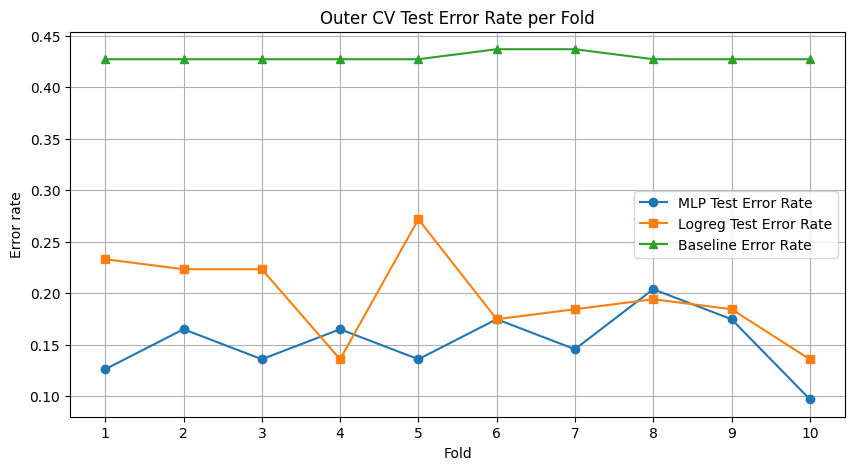

In [14]:
# Plot outer CV test Error rate per Fold for every model
folds = results_df['Fold'].values
mlp_error = results_df['MLP Error'].values
logreg_error = results_df['LogReg Error'].values
baseline_error = results_df['Baseline Error'].values

plt.figure(figsize=(10,5))
plt.plot(folds, mlp_error, marker='o', label='MLP Test Error Rate')
plt.plot(folds, logreg_error, marker='s', label='Logreg Test Error Rate')
plt.plot(folds, baseline_error, marker='^', label='Baseline Error Rate')
plt.xlabel('Fold')
plt.ylabel('Error rate')
plt.title('Outer CV Test Error Rate per Fold')
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()


In [15]:
# For Logistic Regression
logreg_params = results_df['C*']
most_common_logreg = logreg_params.mode()[0]
print("Most frequent LogReg C:", most_common_logreg)

# For MLP
mlp_params_df = results_df[['h*', 'λ*']]
most_common_mlp = mlp_params_df.value_counts().idxmax()
print("Most frequent MLP configuration:", most_common_mlp)

Most frequent LogReg C: 100
Most frequent MLP configuration: ((16, 16), np.float64(0.0001))


In [16]:
numeric_results = results_df[['Baseline Error', 'LogReg Error', 'MLP Error']].copy()

# Compute mean values +/- STD
summary = numeric_results.agg(['mean', 'std'])
summary_row = summary.apply(lambda x: f"{x['mean']:.3f} ± {x['std']:.3f}")
print(summary_row)

Baseline Error    0.429 ± 0.004
LogReg Error      0.196 ± 0.043
MLP Error         0.152 ± 0.030
dtype: object


In [17]:
# McNemar's test

y_true_all = np.concatenate([r['y_true'] for r in predictions])
y_pred_baseline = np.concatenate([r['y_pred_base'] for r in predictions])
y_pred_logreg = np.concatenate([r['y_pred_logreg'] for r in predictions])
y_pred_mlp = np.concatenate([r['y_pred_mlp'] for r in predictions])

def mcnemar_test(y_true, y_pred_model1, y_pred_model2):
    n12 = np.sum((y_pred_model1 == y_true) & (y_pred_model2 != y_true))
    n21 = np.sum((y_pred_model1 != y_true) & (y_pred_model2 == y_true))

    table = [[0, n12],
            [n21, 0]]

    result = mcnemar(table, exact=True)

    print(f"n12 = {n12}, n21 = {n21}")
    print(f"McNemar statistic = {result.statistic}, p-value = {result.pvalue}")

print("Baseline vs Logistic Regression:")
mcnemar_test(y_true_all, y_pred_baseline, y_pred_logreg)

print("\nBaseline vs MLP:")
mcnemar_test(y_true_all, y_pred_baseline, y_pred_mlp)

print("\nMLP vs Logistic Regression:")
mcnemar_test(y_true_all, y_pred_mlp, y_pred_logreg)


Baseline vs Logistic Regression:
n12 = 93, n21 = 333
McNemar statistic = 93.0, p-value = 9.088536565190332e-33

Baseline vs MLP:
n12 = 70, n21 = 355
McNemar statistic = 70.0, p-value = 5.652001753569024e-47

MLP vs Logistic Regression:
n12 = 93, n21 = 48
McNemar statistic = 48.0, p-value = 0.00018818083935730518


In [18]:
# Final logistic regression model

# Final logistic regression pipeline
C_mode = results_df["C*"].mode()[0]
final_logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("final_logreg", LogisticRegression(
        C = C_mode,
        max_iter=2000,
        multi_class="multinomial",
        solver="lbfgs",
        random_state=42
    ))
])

final_logreg_pipeline.fit(X, y_classes)

final_logreg = final_logreg_pipeline.named_steps["final_logreg"]
coef_df = pd.DataFrame(final_logreg.coef_, columns=X.columns, index=[f"class={c}" for c in final_logreg.classes_])
intercepts = pd.Series(final_logreg.intercept_, index=coef_df.index, name="intercept")
display(pd.concat([intercepts, coef_df], axis=1))

,intercept,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day)
class=0,-1.982639,-3.029283,-2.095803,-1.313150,0.444569,-0.338878,-0.474331,-0.561514,-6.210161
class=1,2.797445,0.048740,-0.129549,-0.247738,0.298543,0.249237,-0.073755,-0.052235,2.542202
class=2,-0.814806,2.980542,2.225353,1.560888,-0.743113,0.089641,0.548086,0.613750,3.667959


In [21]:
# # Predictions
X_train, X_test, y_train, y_test = train_test_split(X, y_classes, test_size=0.2, random_state=42, stratify=y_classes)

y_pred_final_logreg = final_logreg_pipeline.predict(X_test)

# # Accuracy and classification report
final_logreg_acc = accuracy_score(y_test, y_pred_final_logreg)
print("Accuracy:", final_logreg_acc)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_final_logreg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_final_logreg))


Accuracy: 0.8495145631067961

Confusion Matrix:
 [[ 47  12   0]
 [  6 107   5]
 [  0   8  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        59
           1       0.84      0.91      0.87       118
           2       0.81      0.72      0.76        29

    accuracy                           0.85       206
   macro avg       0.85      0.81      0.83       206
weighted avg       0.85      0.85      0.85       206

